<a href="https://colab.research.google.com/github/mirian2004/AI-AI-/blob/Day09/Day9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**SGD vs Adam Optimizer 성능 실험**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

**학습 데이터 시각화**

동일한 환경에서 Optimizer만 다르게 설정하여 학습을 진행함

데이터 크기: torch.Size([1000, 2])


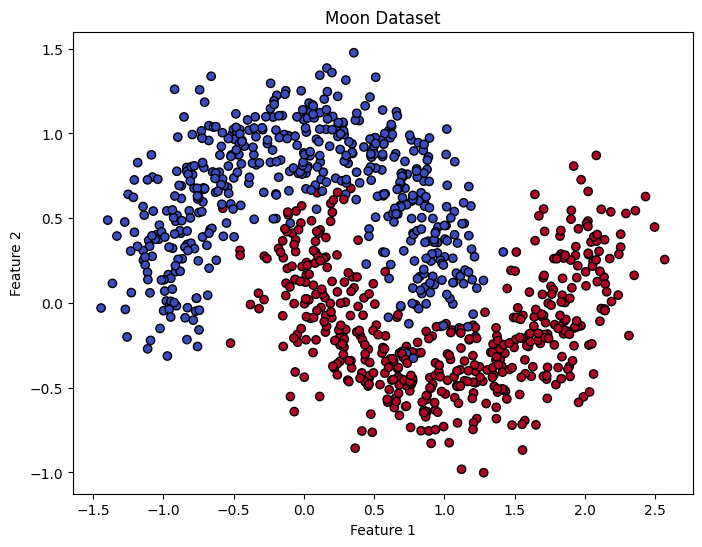

In [2]:
# 1. 데이터 준비 (Moon 데이터셋)
# 반달 모양의 데이터 1000개 생성
X,y = make_moons(n_samples=1000, noise=0.2, random_state=42)

# Pytorch 텐서로 변환 (Float형)
X = torch.FloatTensor(X)
y = torch.FloatTensor(y).unsqueeze(1)

print(f"데이터 크기: {X.shape}")

plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], c=y.squeeze(), cmap='coolwarm', edgecolor='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Moon Dataset')
plt.show()

**모델 설정 및 초기화**

2개의 층으로 구성된 모델을 총 2개 선언한 후 동일한 상태로 고정함

In [3]:
# 2. 모델 정의 (2-Layer Neural Network)
# 두 실험(SGD용, Adam용) 에 사용할 동일한 구조의 모델 클래서
class SimpleNN(nn.Module):
  def __init__(self):
    super(SimpleNN, self).__init__()
    self.layer1 = nn.Linear(2, 64) # 입력 2개 -> 은닉 64개
    self.relu = nn.ReLU()
    self.layer2 = nn.Linear(64, 1) # 은닉 64개 -> 출력 1개
    self.sigmoid = nn.Sigmoid() # 확률값(0~1) 변환

  def forward(self, x):
    x = self.layer1(x)
    x = self.relu(x)
    x = self.layer2(x)
    x = self.sigmoid(x)
    return x

# 두 개의 똑같은 모델 생성 (초기 가중치도 비슷하게 출발한다고 가정)
torch.manual_seed(42) # 공정한 비교를 위해 시드 고정
model_sgd = SimpleNN()
model_adam = SimpleNN()

# 모델의 초기 상태를 완벽히 똑같이 맞춤
model_adam.load_state_dict(model_sgd.state_dict())

<All keys matched successfully>

**Optimizer 설정**

기존 SGD와 모멘텀 및 학습률 조절 기법이 적용된 Adam optimizer을 설정함.
두 모델을 각각 optimizer로 최적화하도록 설정함
이진 분류 문제이므로 Binary Cross Entropy(BCE) Loss를 사용함

In [4]:
# 3. Optimizer 설정
# SGD: 학습률 0.01
optimizer_sgd = optim.SGD(model_sgd.parameters(), lr=0.01)

# Adam: 학습률 0.01 (관성 + 보폭 조절)
optimizer_adam = optim.Adam(model_adam.parameters(), lr=0.01)

# 손실 함수 (이진 분류이므로 BCELoss 사용)
criterion = nn.BCELoss()

**모델 학습**

100 Epoch 동안 각 모델을 각각의 Optimizer로 학습함
학습 과정 중 Loss를 저장함으로써 학습 결과를 비교하고자 함

In [5]:
from torch.nn.modules import loss
# 4. 비교 학습 진행
epochs = 100
loss_history_sgd = []
loss_history_adam = []

print("\n Optimizer 성능 비교 시작...\n")

for epoch in range(epochs):
  # --- [실험 1] SGD 학습 ---
  optimizer_sgd.zero_grad() # 기울기 초기화
  pred_sgd = model_sgd(X) # 예측
  loss_sgd = criterion(pred_sgd, y) # Loss 계산
  loss_sgd.backward() # 역전파
  optimizer_sgd.step() # 가중치 업데이트 (SGD)
  loss_history_sgd.append(loss_sgd.item())

  # --- [실험 2] Adam 학습 ---
  optimizer_adam.zero_grad() # 기울기 초기화
  pred_adam = model_adam(X) # 예측
  loss_adam = criterion(pred_adam, y) # Loss 계산
  loss_adam.backward() # 역전파
  optimizer_adam.step() # 가중치 업데이트 (Adam)
  loss_history_adam.append(loss_adam.item())

  if (epoch+1) % 10 == 0:
    print(f"Epoch {epoch+1:3d} | SGD Loss: {loss_sgd.item():.4f} | Adam Loss: {loss_adam.item():.4f}")


 Optimizer 성능 비교 시작...

Epoch  10 | SGD Loss: 0.7154 | Adam Loss: 0.4597
Epoch  20 | SGD Loss: 0.6799 | Adam Loss: 0.3336
Epoch  30 | SGD Loss: 0.6492 | Adam Loss: 0.2713
Epoch  40 | SGD Loss: 0.6224 | Adam Loss: 0.2374
Epoch  50 | SGD Loss: 0.5987 | Adam Loss: 0.2182
Epoch  60 | SGD Loss: 0.5776 | Adam Loss: 0.1979
Epoch  70 | SGD Loss: 0.5588 | Adam Loss: 0.1781
Epoch  80 | SGD Loss: 0.5419 | Adam Loss: 0.1593
Epoch  90 | SGD Loss: 0.5267 | Adam Loss: 0.1422
Epoch 100 | SGD Loss: 0.5129 | Adam Loss: 0.1276


**Optimizer 별 학습 결과 비교**

저장된 Loss를 시각화 함

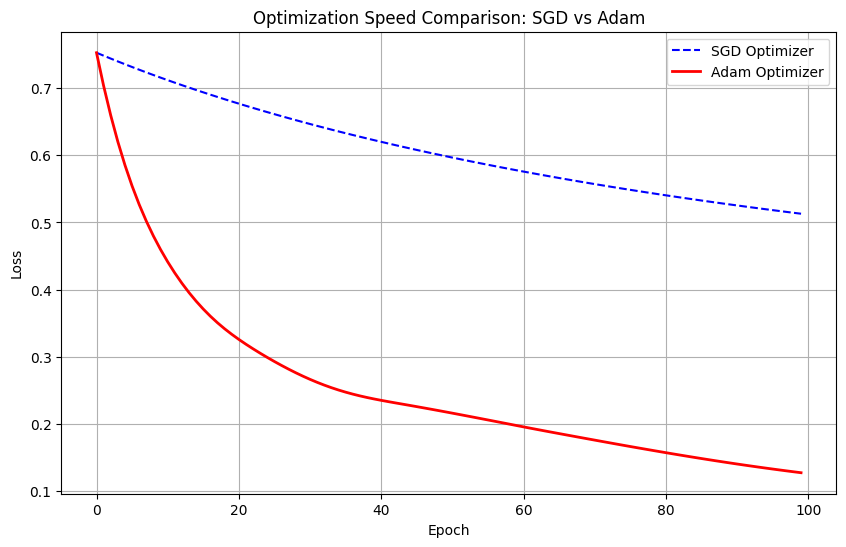


 최종 결과 비교
SGD 최종 Loss : 0.5129
Adam 최종 Loss : 0.1276


In [6]:
# 5. 비교 결과 시각화
plt.figure(figsize=(10,6))

plt.plot(loss_history_sgd, label='SGD Optimizer', color='blue', linestyle='--')
plt.plot(loss_history_adam, label='Adam Optimizer', color='red', linewidth=2)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Optimization Speed Comparison: SGD vs Adam')
plt.legend()
plt.grid(True)
plt.show()

# 최종 결과 요약
print(f"\n 최종 결과 비교")
print(f"SGD 최종 Loss : {loss_history_sgd[-1]:.4f}")
print(f"Adam 최종 Loss : {loss_history_adam[-1]:.4f}")

Adam이 SGD 보다 학습이 빠르게 수렴하는 것을 확인할 수 있음

SGD : Loss가 천천히 선형적으로 감소하는 경향을 보임. 국소 최저점/평탄한 지점에서 업데이트 속도가 느려지기 때문.

Adam : 학습 초기에 Loss가 수직에 가깝게 감소. Momentum이 초기 가속도를 제공하고, 적응형 학습률이 최적의 보폭을 찾아줬기 때문.
결과적으로 100 epoch에서 SGD보다 훨씬 낮은 Loss 값을 기록함